In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from Model_cpmp import create_model,save_model,load_model
from keras.utils import plot_model
from data_json import load_data_from_json
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
def cosine_Similarity(y_predict, y_test):
    """
    The puspuse of this function is to verify if the values
    predicted by a multiclass classification deep learning
    mechanism are correct or not.

    Input:

        y_predict (list): Values predicted by the machine 
                          learning.
        y_test (list): Actual values for each case.
    
    Return:
        float: Proportion of correctly predicted values over 
        the total number of cases.
    """
    size = len(y_predict)
    suma = 0

    for i in range(size):
        result = np.dot(y_predict[i], y_test[i]) / (np.linalg.norm(y_predict[i]) * np.linalg.norm(y_test[i]))
        suma += result
    
    return suma / size

In [4]:
model = load_model("Models/Model_v6.h5")

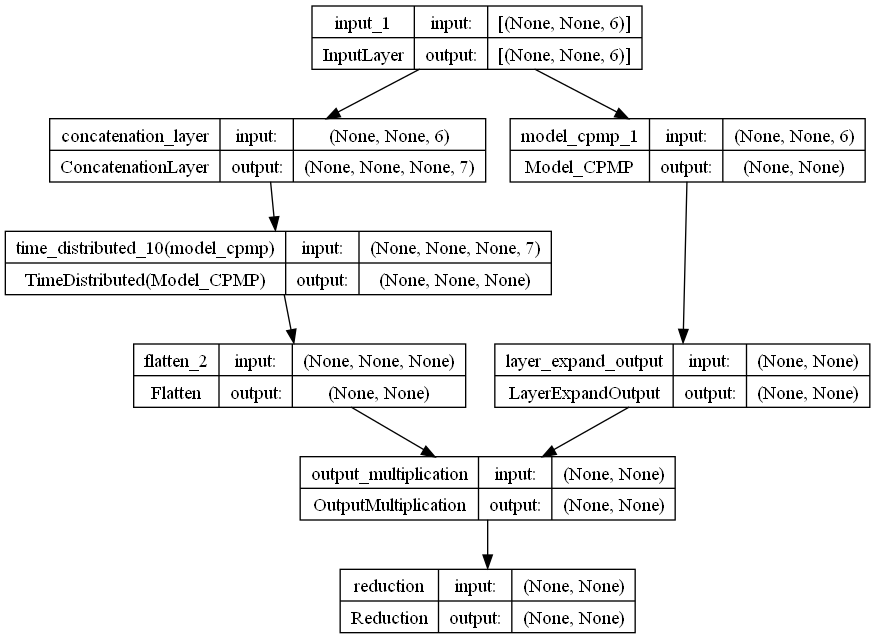

In [5]:
plot_model(model,show_shapes=True,show_layer_names=True)

In [6]:
states, labels = load_data_from_json(name_file="Data/data_5x5_v2.json")

In [7]:
X_train, X_test, y_train, y_test = train_test_split(states, labels, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((200000, 5, 6), (50000, 5, 6), (200000, 20), (50000, 20))

In [9]:
records = model.fit(x=X_train,y=y_train,batch_size=64,epochs=50)

Epoch 1/50
 634/3125 [=====>........................] - ETA: 1:44 - loss: 0.3505 - mae: 0.1989 - mse: 0.0994

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize= (10, 6))

plt.subplot(2, 2, 1)
plt.xlabel("# Epocas")
plt.ylabel("Perdida")
plt.plot(records.history['loss'])

plt.subplot(2, 2, 2)
plt.xlabel("# Epocas")
plt.ylabel("MAE")
plt.plot(records.history['mae'])

plt.subplot(2, 2, 3)
plt.xlabel("# Epocas")
plt.ylabel("MSE")
plt.plot(records.history['mse'])

plt.suptitle('Aprendizaje del modelo')
plt.tight_layout()
plt.show()

In [ ]:
predict = model.predict(X_test)

In [ ]:
results_1 = cosine_Similarity(predict, y_test)
results_2 = mean_absolute_error(y_test, predict)
results_3 = mean_squared_error(y_test, predict)

print(f'Precisión del modelo: {round(results_1 * 100, 3)}%')
print(f'Error Absoluto Medio: {round(results_2 * 100, 3)}%')
print(f'Error cuadratico medio: {round(results_3 * 100, 3)}%')